# <u>Curtailment of Renewables — Allemagne</u>

Ce notebook présente l'analyse complète du curtailment des énergies renouvelables en **Allemagne** (2024–2025).

**Questions de recherche :**
- *How often* do curtailment events occur?
- *Under which conditions* (prix, réseau, météo) ?
- *For which renewables* (éolien vs solaire) ?

The aim of this notebook is to present the complete analysis conducted in this project. We investigate the occurrence of negative day-ahead electricity prices in a power system with a high share of renewable energy. Particular attention is paid to their temporal dynamics, underlying fundamental drivers (supply–demand balance, exports, weather) and the distinction between wind and solar curtailment.

## <u>1. Necessary imports</u>

In [1]:
from pathlib import Path
import math
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scripts.data as dl
import scripts.plots as pl

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Country selection — change to 'france' to run the French analysis
COUNTRY = 'allemagne'

## <u>2. Data load and processing</u>

The data for Germany (2024–2025) are obtained from the **SMARD platform** (Bundesnetzagentur) and **energy-charts.info** (ENTSO-E transparency platform).

Sources : génération réelle, consommation, prix day-ahead, prévisions, flux transfrontaliers, capacités installées, coûts TSO, météo (Open-Meteo).

Le chargement est centralisé dans `dl.load_data(country)` qui lit les CSV, déduplique les timestamps DST, et applique le mapping de colonnes pour l'Allemagne.

In [3]:
df_raw = dl.load_data(COUNTRY)
print(f'Données chargées : {df_raw.shape[0]} heures x {df_raw.shape[1]} colonnes')
print(f'Période : {df_raw.index.min()} -> {df_raw.index.max()}')
df_raw.head(3)

Données chargées : 70144 heures x 76 colonnes
Période : 2018-01-01 00:00:00 -> 2026-01-01 23:00:00


,price,price_de_lu,Belgium [€/MWh] Calculated resolutions,price_dk1,Denmark 2 [€/MWh] Calculated resolutions,price_fr,price_nl,Norway 2 [€/MWh] Calculated resolutions,price_at,price_pl,Sweden 4 [€/MWh] Calculated resolutions,price_ch,Czech Republic [€/MWh] Calculated resolutions,DE/AT/LU [€/MWh] Calculated resolutions,Northern Italy [€/MWh] Calculated resolutions,Slovenia [€/MWh] Calculated resolutions,Hungary [€/MWh] Calculated resolutions,load,load_incl_pumped,pumped_consumption,residual_load_tso,biomass,hydro,wind_off,wind_on,...,Luxembourg (import) [MWh] Calculated resolutions,Sweden (export) [MWh] Calculated resolutions,Sweden (import) [MWh] Calculated resolutions,Austria (export) [MWh] Calculated resolutions,Austria (import) [MWh] Calculated resolutions,France (export) [MWh] Calculated resolutions,France (import) [MWh] Calculated resolutions,Poland (export) [MWh] Calculated resolutions,Poland (import) [MWh] Calculated resolutions,Norway (export) [MWh] Calculated resolutions,Norway (import) [MWh] Calculated resolutions,Belgium (export) [MWh] Calculated resolutions,Belgium (import) [MWh] Calculated resolutions,cap_biomass,cap_hydro,cap_wind_off,cap_wind_on,cap_solar,cap_other_res,cap_nuclear,cap_lignite,cap_coal,cap_gas,cap_hydro_pumped,cap_other_conv
Start date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,NaN,NaN,14.16,21.80,26.33,6.74,27.20,26.33,NaN,NaN,26.33,36.99,-10.00,-5.27,45.73,4.90,4.29,45342.00,46681.75,1339.75,13924.25,4704.50,1805.75,2914.25,28503.50,...,0.00,76.00,0.00,2903.00,0.00,1390.00,0.00,1120.00,0.00,NaN,NaN,NaN,NaN,7398.00,NaN,NaN,51787.00,42805.00,NaN,NaN,NaN,NaN,31331.00,NaN,NaN
2018-01-01 01:00:00,NaN,NaN,4.74,26.43,26.43,4.74,27.30,26.43,NaN,NaN,26.43,31.08,-19.00,-29.99,44.16,3.00,0.22,44178.75,45913.00,1734.25,11543.00,4673.25,1673.25,2997.75,29638.00,...,0.00,76.00,0.00,3196.00,0.00,1810.00,0.00,1133.00,0.00,NaN,NaN,NaN,NaN,7398.00,NaN,NaN,51787.00,42805.00,NaN,NaN,NaN,NaN,31331.00,NaN,NaN
2018-01-01 02:00:00,NaN,NaN,3.66,26.10,26.10,3.66,30.10,26.10,NaN,NaN,26.10,29.17,-20.10,-56.65,42.24,1.00,0.21,43073.75,45897.75,2824.00,9806.75,4666.75,1668.25,3093.25,30173.75,...,0.00,76.00,0.00,3218.00,0.00,1651.00,0.00,1205.00,0.00,NaN,NaN,NaN,NaN,7398.00,NaN,NaN,51787.00,42805.00,NaN,NaN,NaN,NaN,31331.00,NaN,NaN


In [4]:
df_raw.columns.tolist()

['price',
 'price_de_lu',
 'Belgium [€/MWh] Calculated resolutions',
 'price_dk1',
 'Denmark 2 [€/MWh] Calculated resolutions',
 'price_fr',
 'price_nl',
 'Norway 2 [€/MWh] Calculated resolutions',
 'price_at',
 'price_pl',
 'Sweden 4 [€/MWh] Calculated resolutions',
 'price_ch',
 'Czech Republic [€/MWh] Calculated resolutions',
 'DE/AT/LU [€/MWh] Calculated resolutions',
 'Northern Italy [€/MWh] Calculated resolutions',
 'Slovenia [€/MWh] Calculated resolutions',
 'Hungary [€/MWh] Calculated resolutions',
 'load',
 'load_incl_pumped',
 'pumped_consumption',
 'residual_load_tso',
 'biomass',
 'hydro',
 'wind_off',
 'wind_on',
 'solar',
 'other_res',
 'nuclear',
 'lignite',
 'coal',
 'gas',
 'hydro_pumped',
 'other_conv',
 'load_forecast',
 'residual_load_forecast_tso',
 'total_generation_forecast',
 'vre_forecast_total',
 'wind_off_forecast',
 'wind_on_forecast',
 'solar_forecast',
 'Other [MWh] Original resolutions',
 'net_export_total',
 'Netherlands (export) [MWh] Calculated resolut

In [5]:
yearly_summary = (
    df_raw.assign(year=df_raw.index.year)
    .groupby('year')
    .agg(
        n_hours=('price', 'size'),
        price_na_share=('price', lambda x: x.isna().mean()),
        neg_price_share=('price', lambda x: (x < 0).mean()),
    )
)
yearly_summary

,n_hours,price_na_share,neg_price_share
year,,,
2018,8759,0.75,0.00
2019,8759,0.00,0.02
2020,8783,0.00,0.03
2021,8759,0.00,0.02
2022,8759,0.00,0.01
2023,8759,0.00,0.03
2024,8783,0.00,0.05
2025,8759,0.00,0.07
2026,24,0.00,0.08


Before this stage, the raw data have not yet been processed and may contain duplicates. These duplicates mainly arise from daylight saving time changes (e.g., the transition between summer and winter time). They are handled automatically inside `dl.load_data()` by averaging over duplicate timestamps.

In [6]:
miss = df_raw.isnull().mean().sort_values(ascending=False)
miss[miss > 0].round(4).to_frame('missing_share')

,missing_share
cap_nuclear,1.00
DE/AT/LU [€/MWh] Calculated resolutions,0.91
cap_other_conv,0.75
cap_lignite,0.75
cap_wind_off,0.75
cap_coal,0.62
cap_other_res,0.62
cap_hydro_pumped,0.50
cap_hydro,0.50
net_export_total,0.34


Note that several columns exhibit a relatively high number of missing values. At this stage, we retain these variables to gain preliminary insights into the data, with the understanding that they may be removed later if deemed uninformative or problematic.

## <u>3. Feature engineering</u>

At this stage, the objective is to construct a clear and interpretable dataset that can be used both for exploratory analysis and for modeling negative electricity price events. Feature engineering focuses on:
- Aggregating generation by technology (wind total, VRE real total, thermal total, renewable total)
- Building physical indicators: residual load, generation–load balance, capacity factors
- Deriving a **curtailment proxy**: hours where forecast–actual gap > 50 MWh **AND** price < 10 €/MWh
- Encoding time features (hour_sin/cos, is_weekend)

In [ ]:
df_final = dl.add_features(df_raw)

keep_cols = [
    # --- Target & Prices ---
    'price', 'price_de_lu', 'price_fr', 'price_nl', 'price_at',
    'price_pl', 'price_dk1', 'price_ch', 'is_negative',

    # --- Demand & System State ---
    'load', 'load_incl_pumped', 'pumped_consumption', 'residual_load_tso',
    'net_export_total', 'generation_load_balance', 'residual_load',

    # --- Generation Real (Actuals) ---
    'nuclear', 'biomass', 'lignite', 'coal', 'gas',
    'hydro_pumped', 'hydro',
    'wind_off', 'wind_on', 'solar',
    'other_res', 'other_conv',
    'wind_total', 'renewable_total', 'thermal_total', 'vre_real_total',

    # --- Installed Capacity (MW) ---
    'cap_wind_on', 'cap_wind_off', 'cap_solar',
    'cap_biomass', 'cap_nuclear',
    'cap_hydro', 'cap_hydro_pumped',
    'cap_lignite', 'cap_coal', 'cap_gas',
    'cap_other_res', 'cap_other_conv',

    # --- Forecasts ---
    'load_forecast', 'residual_load_forecast_tso',
    'wind_off_forecast', 'wind_on_forecast', 'solar_forecast',
    'vre_forecast_total', 'total_generation_forecast',
    'wind_forecast_total', 'residual_load_forecast',
    'vre_penetration_forecast',

    # --- Curtailment Analysis (Engineered) ---
    'curtailment_raw_gap',
    'curtailment_mwh',
    'is_curtailment_likely',
    'wind_capacity_factor',
    'solar_capacity_factor',

    # --- Time features ---
    'hour_sin', 'hour_cos', 'is_weekend', 'weekday', 'hour',
]

keep_cols = [c for c in keep_cols if c in df_final.columns]
df_model = df_final[keep_cols].copy()
print(f'df_model : {df_model.shape[0]} heures x {df_model.shape[1]} colonnes')
df_model.head(3)

df_model : 63569 heures x 64 colonnes


,price,price_de_lu,price_fr,price_nl,price_at,price_pl,price_dk1,price_ch,is_negative,load,load_incl_pumped,pumped_consumption,residual_load_tso,net_export_total,generation_load_balance,residual_load,nuclear,biomass,lignite,coal,gas,hydro_pumped,hydro,wind_off,wind_on,...,cap_lignite,cap_coal,cap_gas,cap_other_res,cap_other_conv,load_forecast,residual_load_forecast_tso,wind_off_forecast,wind_on_forecast,solar_forecast,vre_forecast_total,total_generation_forecast,wind_forecast_total,residual_load_forecast,vre_penetration_forecast,curtailment_raw_gap,curtailment_mwh,is_curtailment_likely,wind_capacity_factor,solar_capacity_factor,hour_sin,hour_cos,is_weekend,weekday,hour
Start date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,59.53,NaN,59.53,59.53,59.53,NaN,50.32,63.06,0,42928.25,46411.25,3483.00,37074.00,NaN,5473.75,37074.00,7894.25,4515.75,15545.25,7946.00,3382.00,41.00,1341.00,1632.25,4222.00,...,NaN,NaN,31331.00,NaN,NaN,44217.25,38358.00,1617.25,4242.00,0.00,5859.25,NaN,5859.25,38358.00,0.13,5.00,0.00,0,NaN,0.00,0.00,1.00,0,0,0
2018-10-01 01:00:00,56.10,NaN,56.10,56.10,56.10,NaN,50.43,58.68,0,41669.50,45614.75,3945.25,35651.50,NaN,6511.50,35651.50,7907.00,4485.25,15605.75,7761.75,3249.25,0.00,1245.75,2078.25,3939.75,...,NaN,NaN,31331.00,NaN,NaN,42760.25,37006.25,1657.50,4096.50,0.00,5754.00,NaN,5754.00,37006.25,0.13,0.00,0.00,0,NaN,0.00,0.26,0.97,0,0,1
2018-10-01 02:00:00,51.41,NaN,51.41,51.41,51.41,NaN,42.40,58.63,0,40900.25,44769.00,3868.75,34896.00,NaN,7288.50,34896.00,7927.00,4491.25,15685.75,7556.75,3328.50,0.00,1276.50,2141.25,3863.00,...,NaN,NaN,31331.00,NaN,NaN,42239.50,36337.00,1750.50,4152.00,0.00,5902.50,NaN,5902.50,36337.00,0.14,0.00,0.00,0,NaN,0.00,0.50,0.87,0,0,2


In [31]:
df_model.columns

Index(['price', 'price_de_lu', 'price_fr', 'price_nl', 'price_at', 'price_pl',
       'price_dk1', 'price_ch', 'is_negative', 'load', 'load_incl_pumped',
       'pumped_consumption', 'residual_load_tso', 'net_export_total',
       'generation_load_balance', 'residual_load', 'nuclear', 'biomass',
       'lignite', 'coal', 'gas', 'hydro_pumped', 'hydro', 'wind_off',
       'wind_on', 'solar', 'other_res', 'other_conv', 'wind_total',
       'renewable_total', 'thermal_total', 'vre_real_total', 'cap_wind_on',
       'cap_wind_off', 'cap_solar', 'cap_biomass', 'cap_nuclear', 'cap_hydro',
       'cap_hydro_pumped', 'cap_lignite', 'cap_coal', 'cap_gas',
       'cap_other_res', 'cap_other_conv', 'load_forecast',
       'residual_load_forecast_tso', 'wind_off_forecast', 'wind_on_forecast',
       'solar_forecast', 'vre_forecast_total', 'total_generation_forecast',
       'wind_forecast_total', 'residual_load_forecast',
       'vre_penetration_forecast', 'curtailment_raw_gap', 'curtailment_mwh',

In [ ]:
df_model = df_final.loc['2024-01-01 00:00:00':'2026-01-01 00:00:00', keep_cols].copy()

In [33]:
yearly_summary_features = (
    df_model.assign(year=df_model.index.year)
    .groupby('year')
    .agg(
        n_hours=('price', 'size'),
        price_na_share=('price', lambda x: x.isna().mean()),
        neg_price_share=('price', lambda x: (x < 0).mean()),
        curtailment_hours=('is_curtailment_likely', 'sum'),
        curtailment_mwh_total=('curtailment_mwh', 'sum'),
    )
)
yearly_summary_features

,n_hours,price_na_share,neg_price_share,curtailment_hours,curtailment_mwh_total
year,,,,,
2023,8759,0.00,0.03,442,1380849.75
2024,8783,0.00,0.05,616,1793647.25
2025,8759,0.00,0.07,560,1655552.98
2026,1,0.00,0.00,0,0.00


In [9]:
missing_share = (
    df_model
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='missing_share')
)
missing_share[missing_share['missing_share'] > 0]

,missing_share
cap_nuclear,1.00
wind_capacity_factor,0.72
cap_lignite,0.72
cap_wind_off,0.72
cap_other_conv,0.72
cap_other_res,0.58
cap_coal,0.58
cap_hydro,0.45
cap_hydro_pumped,0.45
net_export_total,0.27


# <u>Visualisation and first conclusions</u>

In [10]:
# Est-ce qu'on a trouvé du curtailment ?
n_curtailment = df_model['is_curtailment_likely'].sum()
n_total = len(df_model)
pct = 100 * n_curtailment / n_total
print(f'Heures avec curtailment probable : {int(n_curtailment)} / {n_total} ({pct:.1f}%)')
print(f'Volume total curtailé : {df_model["curtailment_mwh"].sum():,.0f} MWh')
print(f'Volume moyen / heure curtailée : {df_model.loc[df_model["is_curtailment_likely"]==1, "curtailment_mwh"].mean():,.0f} MWh')

# Regarde à quoi ça ressemble quand ça arrive
curtailment_events = df_model[df_model['is_curtailment_likely'] == 1]
show_cols = [c for c in ['price', 'curtailment_mwh', 'wind_on', 'solar', 'vre_forecast_total'] if c in curtailment_events.columns]
print(curtailment_events[show_cols].head(10))

Heures avec curtailment probable : 2680 / 63569 (4.2%)
Volume total curtailé : 7,375,674 MWh
Volume moyen / heure curtailée : 2,752 MWh
                     price  curtailment_mwh  wind_on    solar  \
Start date                                                      
2018-10-03 08:00:00   0.70          1031.00 27020.50  1772.75   
2018-10-03 09:00:00   0.91          1530.50 25899.00  4762.50   
2018-10-03 10:00:00  -0.03          1629.75 25343.75  8370.75   
2018-10-03 11:00:00   0.03          1385.25 25691.00 10950.50   
2018-10-03 12:00:00  -0.04          1019.00 25908.00 12176.75   
2018-10-03 13:00:00   0.00           338.75 24928.00 12776.25   
2018-10-23 23:00:00   6.03          1092.50 34863.00     0.00   
2018-10-24 00:00:00   4.07           831.00 34795.25     0.00   
2018-10-24 01:00:00   0.98           900.75 34829.25     0.00   
2018-10-24 02:00:00   0.04          1286.25 34279.75     0.00   

                     vre_forecast_total  
Start date                               

## Correlation Analysis

Les corrélations positives confirment que le curtailment est intrinsèquement lié à l'abondance des énergies renouvelables et aux signaux de prix du marché. La forte corrélation avec la variable `is_negative` valide l'approche économique : le curtailment agit comme une réponse directe aux prix négatifs.

In [11]:
# Quelles colonnes sont les plus liées au curtailment ?
correlations = df_model.corr(numeric_only=True)['curtailment_mwh'].sort_values(ascending=False)
print('=== Top 10 corrélations POSITIVES ===')
print(correlations.head(10))

=== Top 10 corrélations POSITIVES ===
curtailment_mwh            1.00
is_curtailment_likely      0.76
is_negative                0.60
curtailment_raw_gap        0.51
vre_penetration_forecast   0.39
vre_forecast_total         0.33
vre_real_total             0.27
renewable_total            0.27
pumped_consumption         0.23
wind_on_forecast           0.23
Name: curtailment_mwh, dtype: float64


À l'inverse, les corrélations négatives soulignent le rôle déterminant des contraintes physiques et de l'inflexibilité du mix électrique. La variable la plus corrélée négativement, la charge résiduelle (`residual_load_forecast`), est le principal prédicteur du phénomène : plus la demande résiduelle est élevée, moins il y a de curtailment.

In [12]:
# Les corrélations les plus négatives (les facteurs qui 'empêchent' le curtailment)
print('=== Top 10 corrélations NÉGATIVES ===')
print(correlations.tail(10))

=== Top 10 corrélations NÉGATIVES ===
price_nl                     -0.18
price_pl                     -0.18
price                        -0.19
thermal_total                -0.21
lignite                      -0.26
residual_load                -0.31
residual_load_tso            -0.31
residual_load_forecast       -0.36
residual_load_forecast_tso   -0.36
cap_nuclear                    NaN
Name: curtailment_mwh, dtype: float64


## Weather Data & Correlations

We now enrich the analysis with meteorological data (Open-Meteo historical archive, averaged over 6 representative zones in Germany: Nordsee, Niedersachsen, Brandenburg, Bayern, Baden-Württemberg, Thüringen).

Variables disponibles : vitesse du vent à 10 m et 100 m, rayonnement solaire (shortwave & direct), température à 2 m, couverture nuageuse.

In [13]:
weather = dl.load_weather(COUNTRY)
print(f'Météo : {weather.shape[0]} heures x {weather.shape[1]} colonnes')
print(f'Période : {weather.index.min()} -> {weather.index.max()}')
weather.describe().round(2)

Météo : 17544 heures x 6 colonnes
Période : 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,windspeed_10m,windspeed_100m,shortwave_radiation,direct_radiation,temperature_2m,cloudcover
count,17544.00,17544.00,17544.00,17544.00,17544.00,17544.00
mean,3.77,5.98,139.43,84.54,10.49,65.99
std,1.45,2.21,203.19,142.78,7.06,26.43
min,0.74,0.99,0.00,0.00,-7.60,0.00
25%,2.69,4.40,0.00,0.00,4.92,48.50
50%,3.56,5.73,8.00,1.33,10.28,70.50
75%,4.59,7.20,230.33,114.17,15.88,87.17
max,11.29,17.02,881.67,764.33,31.53,100.00


In [14]:
df_w = df_model.join(weather, how='inner')
print(f'Dataset fusionné : {df_w.shape[0]} heures x {df_w.shape[1]} colonnes')

Dataset fusionné : 17542 heures x 70 colonnes


### Heatmap météo × variables énergie

Cette matrice montre les corrélations de Pearson entre chaque variable météo et les principales variables énergétiques (curtailment, prix, production renouvelable, charge résiduelle).

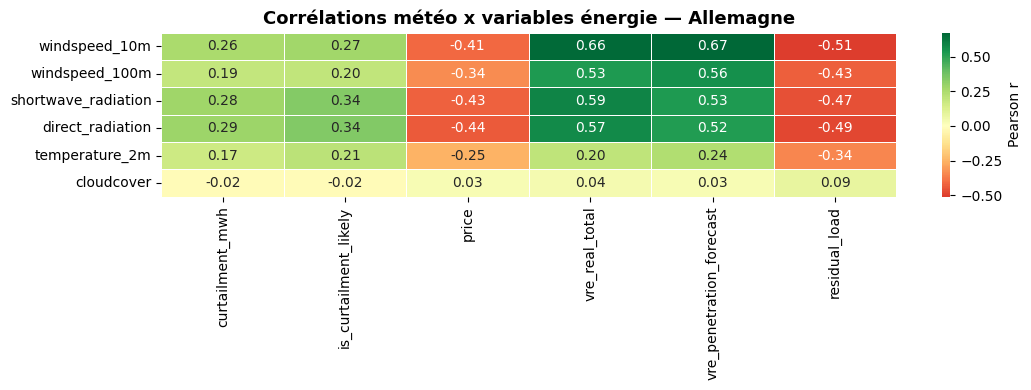

In [15]:
weather_vars = [c for c in weather.columns if c in df_w.columns]
energy_targets = [
    c for c in [
        'curtailment_mwh', 'is_curtailment_likely', 'price',
        'vre_real_total', 'vre_penetration_forecast', 'residual_load'
    ]
    if c in df_w.columns
]

cross_corr = (
    df_w[weather_vars + energy_targets]
    .corr(numeric_only=True)
    .loc[weather_vars, energy_targets]
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    cross_corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(
    f'Corrélations météo x variables énergie — {COUNTRY.capitalize()}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [16]:
weather_corr = df_w[weather_vars + ['curtailment_mwh', 'is_curtailment_likely']].corr(numeric_only=True)

print('=== Corrélations météo -> curtailment_mwh ===')
print(weather_corr['curtailment_mwh'][weather_vars].sort_values(ascending=False).round(3))

print('\n=== Corrélations météo -> is_curtailment_likely ===')
print(weather_corr['is_curtailment_likely'][weather_vars].sort_values(ascending=False).round(3))

=== Corrélations météo -> curtailment_mwh ===
direct_radiation       0.29
shortwave_radiation    0.28
windspeed_10m          0.26
windspeed_100m         0.19
temperature_2m         0.17
cloudcover            -0.02
Name: curtailment_mwh, dtype: float64

=== Corrélations météo -> is_curtailment_likely ===
direct_radiation       0.34
shortwave_radiation    0.34
windspeed_10m          0.27
temperature_2m         0.21
windspeed_100m         0.20
cloudcover            -0.02
Name: is_curtailment_likely, dtype: float64


# <u>Plots</u>

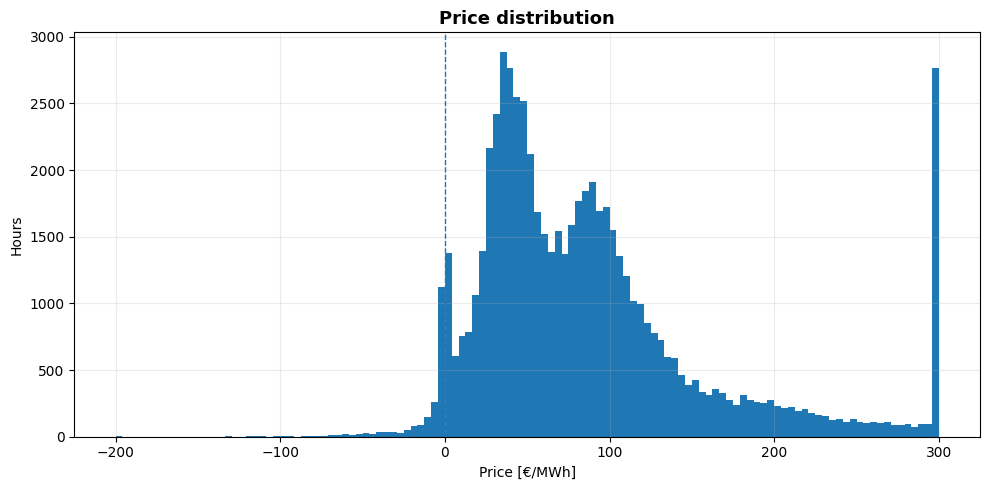

'plots\\curtailment\\allemagne\\price_distribution.png'

In [17]:
# 1. Distribution du prix : Pour montrer la fréquence des prix négatifs (contexte)
pl.plot_price_distribution(df_model, country=COUNTRY)

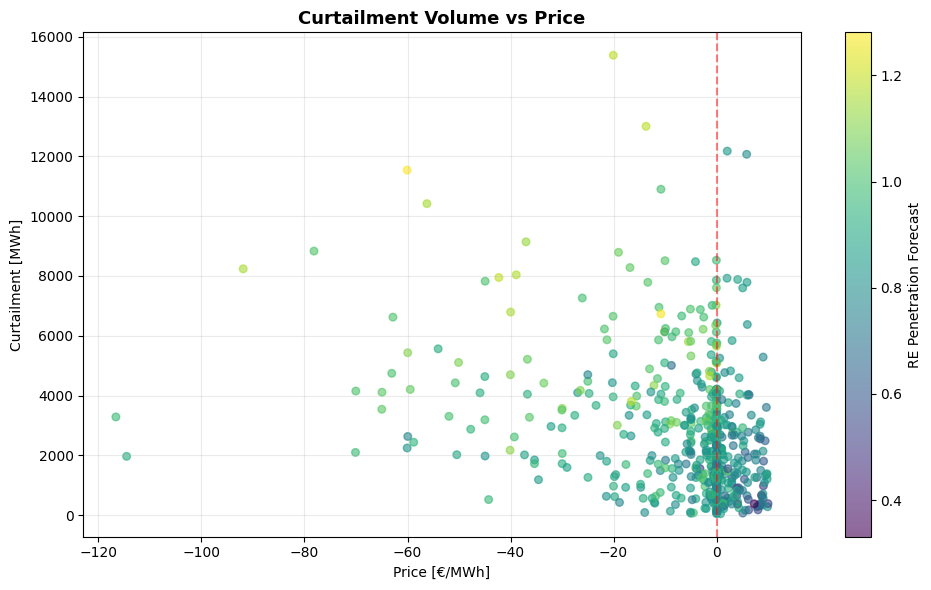

'plots\\curtailment\\allemagne\\curtailment_vs_price.png'

In [18]:
# 2. Corrélation Prix/Curtailment : Pour répondre à 'Under which conditions?' (Économie)
# On s'attend à voir le curtailment exploser quand le prix passe sous 0.
pl.plot_curtailment_v_price_scatter(df_model, country=COUNTRY)

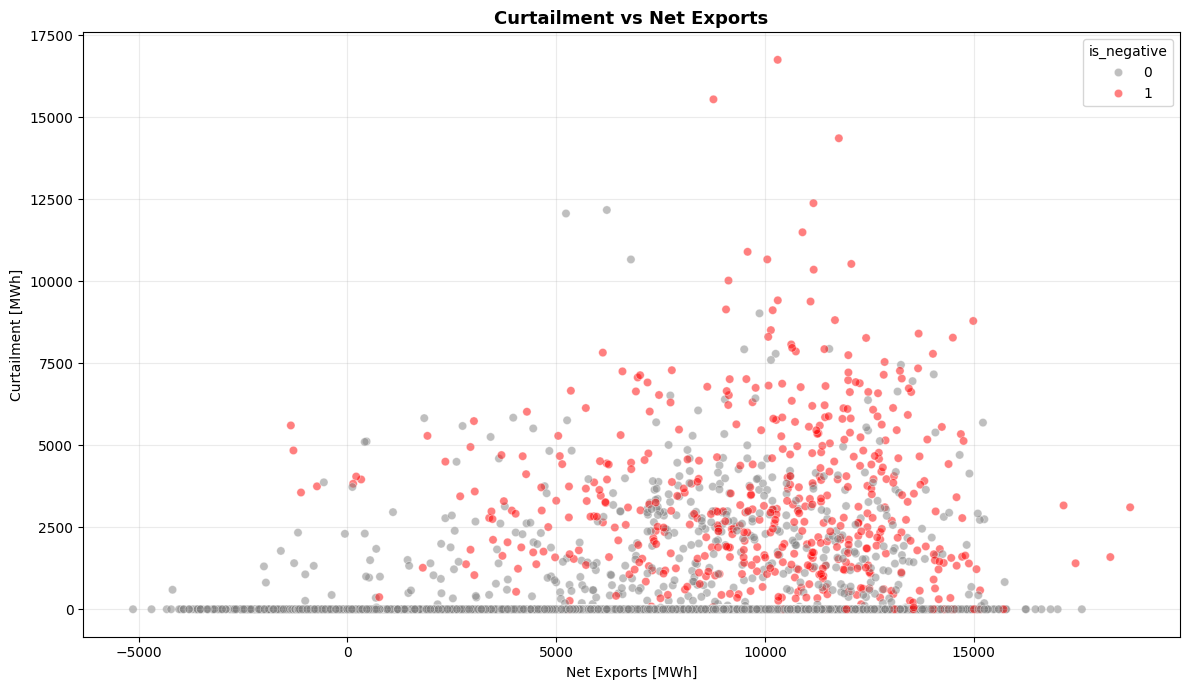

'plots\\curtailment\\allemagne\\export_saturation_logic.png'

In [19]:
# 3. Analyse des Exports : Pour prouver la saturation physique (Réseau)
# On voit si le curtailment n'arrive que quand on exporte déjà au maximum.
pl.plot_export_saturation_curtailment(df_model, country=COUNTRY)

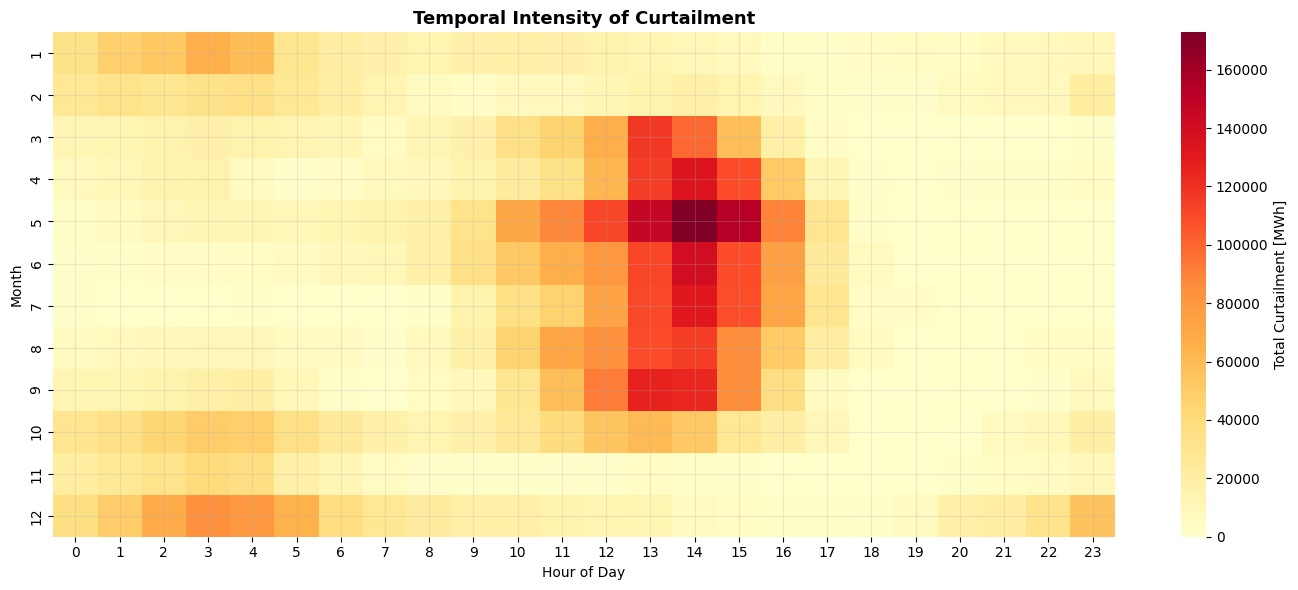

'plots\\curtailment\\allemagne\\curtailment_seasonal_heatmap.png'

In [20]:
# 4. Heatmap saisonnière : Pour répondre à 'How often?' et 'For which renewables?'
# Le solaire apparaîtra l'été à midi, l'éolien l'hiver/nuit.
pl.plot_curtailment_heatmap(df_model, country=COUNTRY)

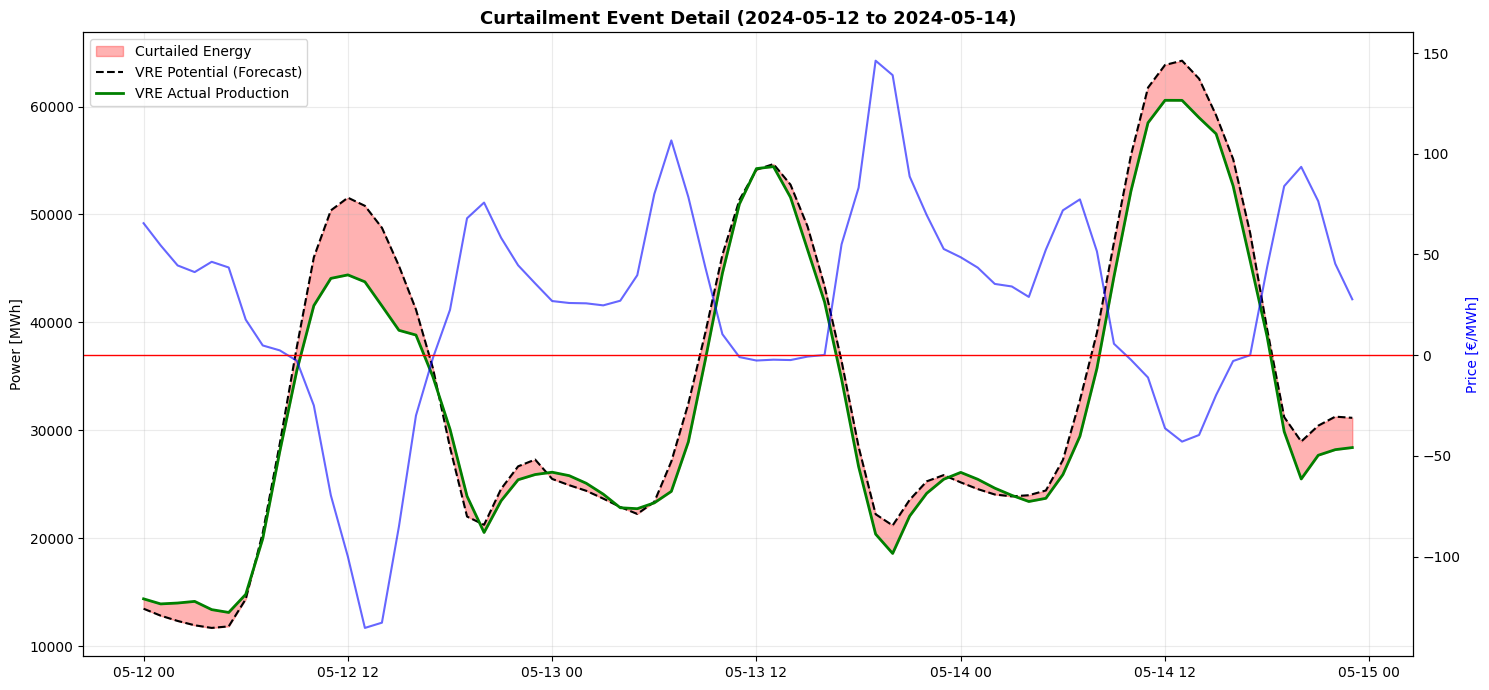

'plots\\curtailment\\allemagne\\curtailment_event_zoom.png'

In [21]:
# 5. Zoom sur un évènement : L'illustration parfaite pour le rapport
# Pentecôte 2024 : week-end prolongé, demande basse + éolien fort
pl.plot_curtailment_event_zoom(df_model, '2024-05-12', '2024-05-14', country=COUNTRY)

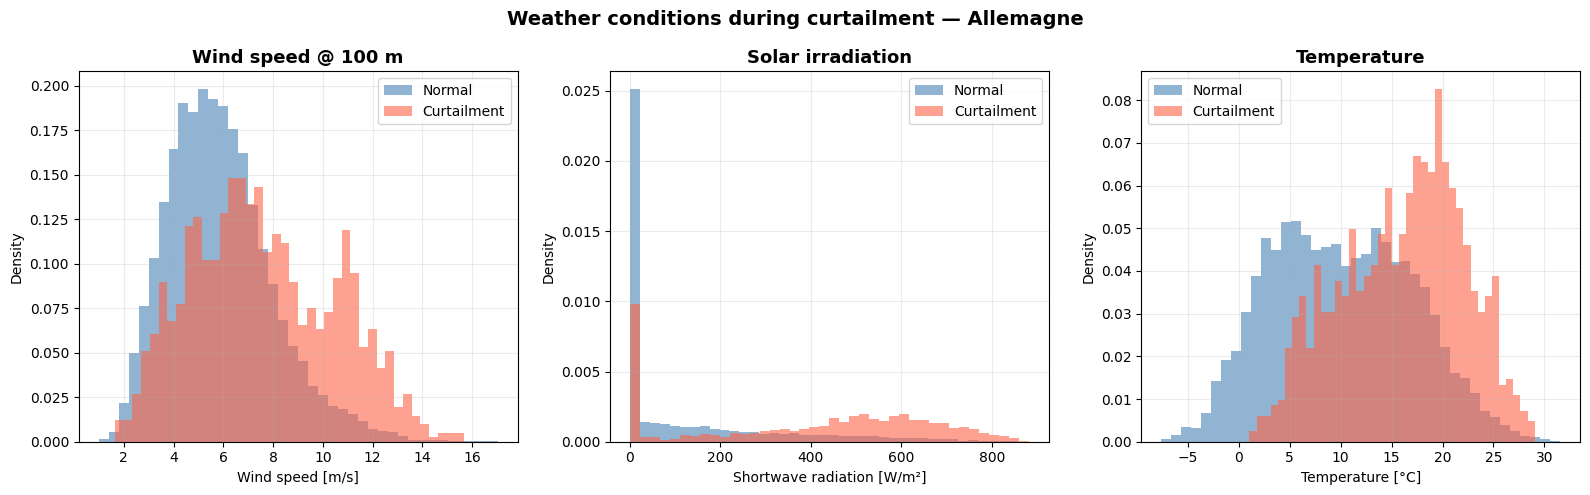

'plots\\curtailment\\allemagne\\weather_curtailment_conditions.png'

In [22]:
# 6. Conditions météo pendant le curtailment vs heures normales
# Répond à : 'Under which conditions?' (météo)
pl.plot_weather_curtailment_conditions(df_model, weather, country=COUNTRY)

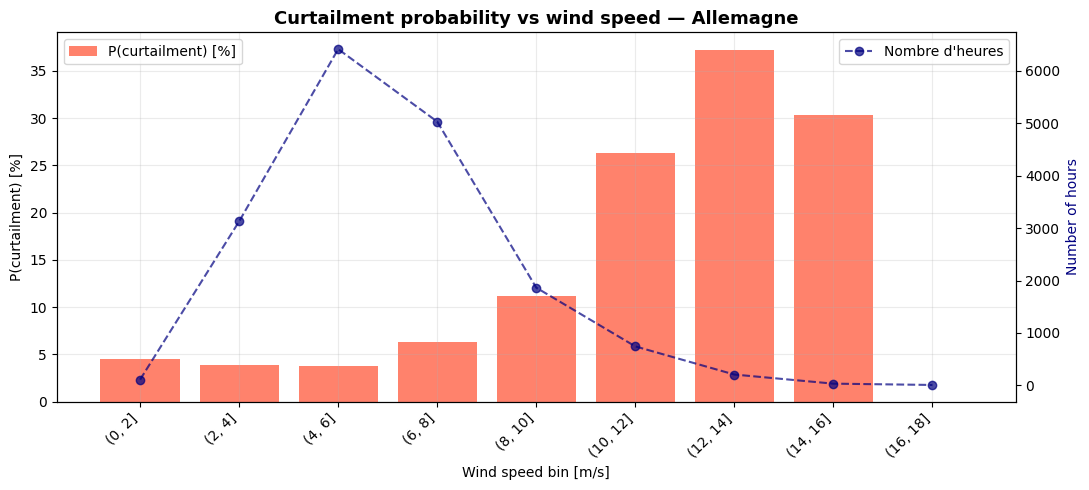

'plots\\curtailment\\allemagne\\curtailment_prob_vs_wind.png'

In [23]:
# 7. Probabilité de curtailment par vitesse de vent (bins de 2 m/s)
# Répond à : 'Under which conditions?' et 'For which renewables?'
pl.plot_curtailment_prob_by_wind(df_model, weather, country=COUNTRY)

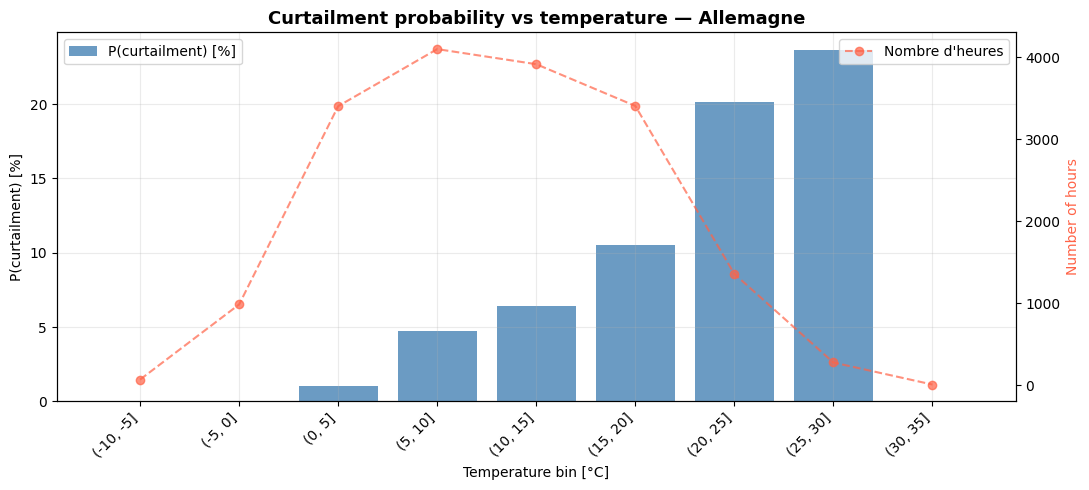

'plots\\curtailment\\allemagne\\curtailment_prob_vs_temperature.png'

In [24]:
# 8. Probabilité de curtailment par tranche de température (5°C)
pl.plot_curtailment_prob_by_temperature(df_model, weather, country=COUNTRY)

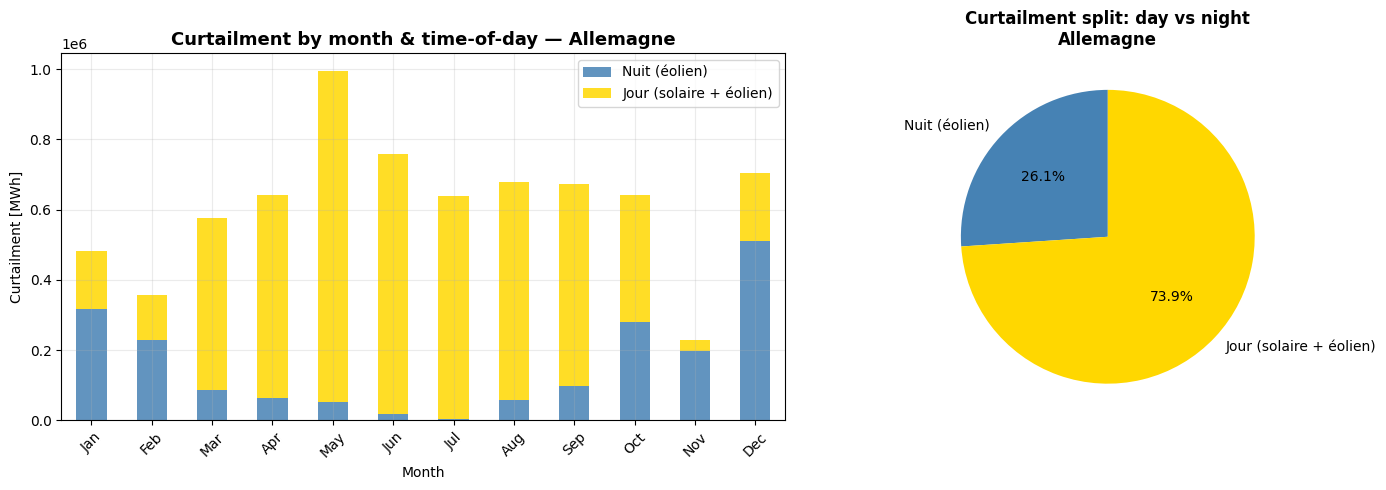

'plots\\curtailment\\allemagne\\curtailment_by_renewable_type.png'

In [25]:
# 9. Décomposition jour/nuit par mois (proxy éolien vs solaire)
# Répond à : 'For which renewables?'
pl.plot_curtailment_by_renewable_type(df_model, country=COUNTRY)

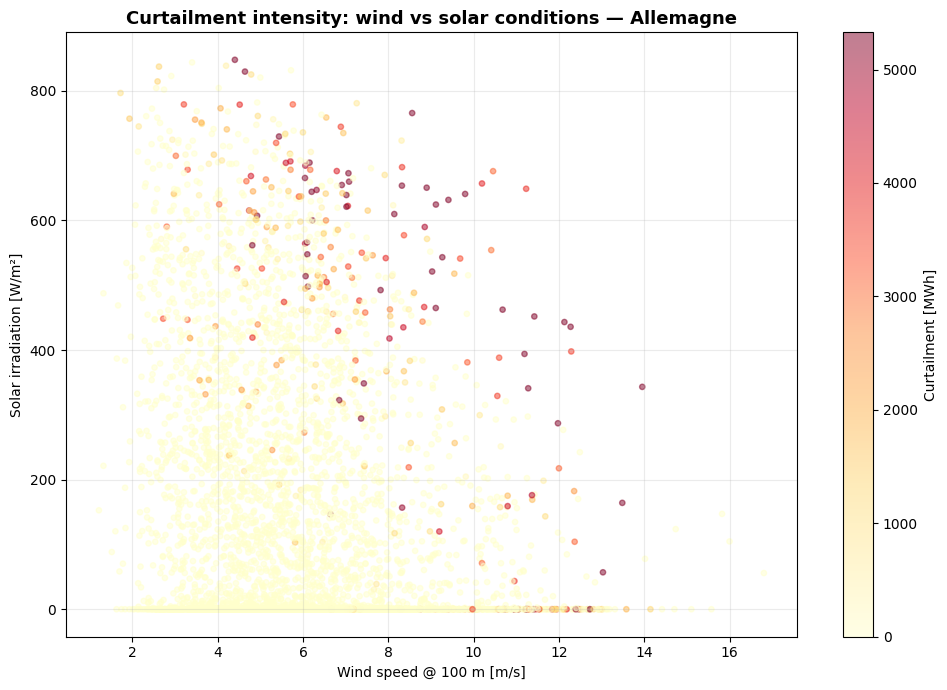

'plots\\curtailment\\allemagne\\curtailment_wind_solar_map.png'

In [26]:
# 10. Carte 2D vitesse vent × rayonnement solaire, colorée par intensité du curtailment
pl.plot_curtailment_wind_solar_scatter(df_model, weather, country=COUNTRY)

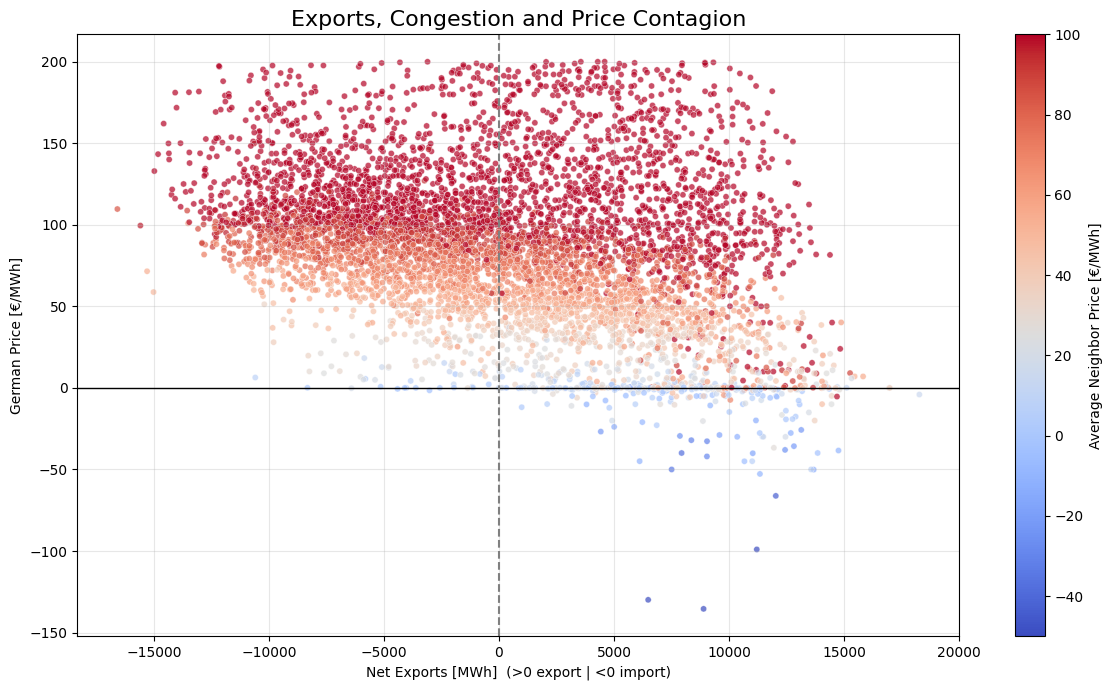

'plots\\curtailment\\allemagne\\exports_and_price.png'

In [27]:
pl.plot_export_congestion_analysis(df_model, country=COUNTRY)

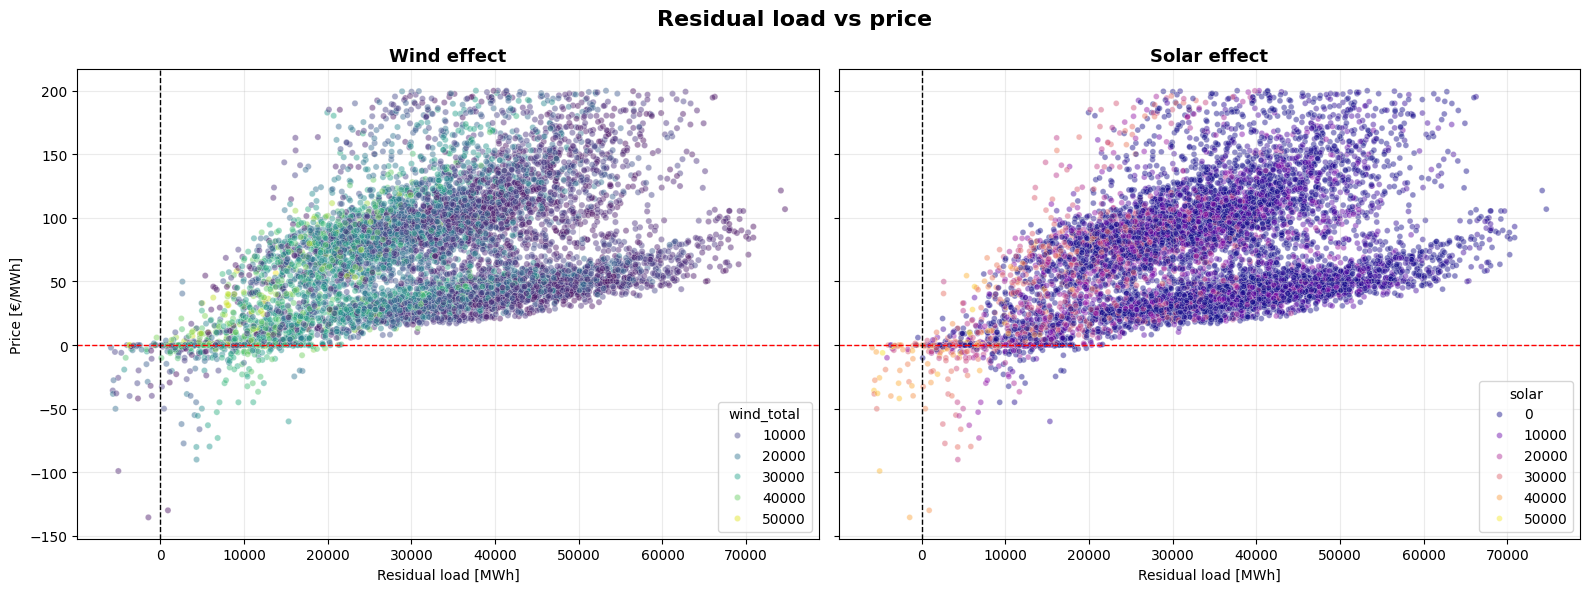

'plots\\curtailment\\allemagne\\residual_load_vs_price.png'

In [29]:
# Analyse offre/demande
pl.plot_residual_load_vs_price(df_model, country=COUNTRY)